In [1]:
import numpy as np

print(np.average([1, 2]))
print(np.average([1, 2], weights=[1, 3]))

1.5
1.75


In [2]:
X = np.array([0, 1])
P = np.array([0.5, 0.5])
print(np.average(X, weights=P))

0.5


In [3]:
print(np.average(X ** 2, weights=P))

0.5


In [4]:
print(np.average(X ** 2, weights=P) - np.average(X, weights=P) ** 2)

0.25


In [5]:
np.random.seed(1)
size = 5
num = 10
sample = np.random.choice(X, p=P, size=(size, num))
print(sample)

[[0 1 0 0 0 0 0 0 0 1]
 [0 1 0 1 0 1 0 1 0 0]
 [1 1 0 1 1 1 0 0 0 1]
 [0 0 1 1 1 0 1 1 0 1]
 [1 1 0 1 0 0 1 0 0 0]]


In [6]:
mean = np.average(sample, axis=0)
print(mean)

[0.4 0.8 0.2 0.8 0.4 0.4 0.4 0.4 0.  0.6]


In [7]:
size = 100
num = 100

%timeit np.random.choice(X, p=P, size=(size, num))
%timeit [np.random.choice(X, p=P, size=size) for _ in range(num)]

176 μs ± 461 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
2.26 ms ± 32.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [8]:
print(np.var(mean))

0.054400000000000004


In [9]:
size = 8
num = 3
maxe = 5
sizeleft = size
total = np.zeros(num)
while sizeleft > 0:
    s = min(sizeleft, maxe)
    sample = np.random.choice(X, p=P, size=(s, num)) 
    print("sample")
    print(f"{sample}")
    print("sum")
    print(f"{np.sum(sample, axis=0)}")
    print()
    total += np.sum(sample, axis=0)  
    sizeleft -= s
print(f"total = {total}")
mean = total / size
print(f"mean  = {mean}")
var = np.var(mean)
print(f"var   = {var}")

sample
[[1 1 0]
 [1 0 1]
 [0 1 0]
 [1 1 1]
 [0 0 0]]
sum
[3 3 2]

sample
[[1 1 1]
 [1 1 0]
 [0 1 0]]
sum
[2 3 1]

total = [5. 6. 3.]
mean  = [0.625 0.75  0.375]
var   = 0.024305555555555552


In [ ]:
size = 8
num = 3
maxe = 5

numleft = num
maxs = min(size, maxe)
maxn = min(num, maxe // maxs)
mean = []
while numleft > 0:
    sizeleft = size
    n = min(numleft, maxn)
    total = np.zeros(n)
    while sizeleft > 0:
        s = min(sizeleft, maxe)
        sample = np.random.choice(X, p=P, size=(s, n)) 
        print("sample")
        print(f"{sample}")
        print("sum")
        print(f"{np.sum(sample, axis=0)}")
        print()
        total += np.sum(sample, axis=0)  
        sizeleft -= s
    print(f"total  = {total}")
    mean += (total / size).tolist()
    print(f"mean   = {mean}")
    numleft -= n
    print()
var = np.var(mean)
print(f"var    = {var}")

sample
[[1]
 [0]
 [0]
 [0]
 [1]]
sum
[2]

sample
[[1]
 [0]
 [1]]
sum
[2]

total  = [4.]
mean   = [0.5]

sample
[[0]
 [0]
 [1]
 [0]
 [1]]
sum
[2]

sample
[[1]
 [0]
 [1]]
sum
[2]

total  = [4.]
mean   = [0.5, 0.5]

sample
[[1]
 [1]
 [1]
 [1]
 [0]]
sum
[4]

sample
[[0]
 [0]
 [1]]
sum
[1]

total  = [5.]
mean   = [0.5, 0.5, 0.625]

var    = 0.0034722222222222225


In [ ]:
size = 8
num = 3
maxe = 20

numleft = num
maxs = min(size, maxe)
maxn = min(num, maxe // maxs)
mean = []
while numleft > 0:
    sizeleft = size
    n = min(numleft, maxn)
    total = np.zeros(n)
    while sizeleft > 0:
        s = min(sizeleft, maxe)
        sample = np.random.choice(X, p=P, size=(s, n)) 
        print("sample")
        print(f"{sample}")
        print("sum")
        print(f"{np.sum(sample, axis=0)}")
        print()
        total += np.sum(sample, axis=0)  
        sizeleft -= s
    print(f"total  = {total}")
    mean += (total / size).tolist()
    print(f"mean   = {mean}")
    numleft -= n
    print()
var = np.var(mean)
print(f"var    = {var}")

sample
[[0 0]
 [1 0]
 [0 1]
 [1 0]
 [0 0]
 [1 0]
 [0 0]
 [0 1]]
sum
[3 2]

total  = [3. 2.]
mean   = [0.375, 0.25]

sample
[[1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]]
sum
[6]

total  = [6.]
mean   = [0.375, 0.25, 0.75]

var    = 0.045138888888888895


In [12]:
a = np.array([[1, 2], [3, 4]])
b = list(a)
c = a.tolist()
print(b)
print(c)

[array([1, 2]), array([3, 4])]
[[1, 2], [3, 4]]


In [ ]:
def sampling_and_analyze(X, P, size, num, maxe=1000000):
    print(f"標本サイズ = {size}")
    E = np.average(X, weights=P)
    V = np.average(X ** 2, weights=P) - E ** 2
    print(f"母平均           = {E:.7f}")
    print(f"母分散           = {V:.7f}")

    numleft = num
    maxs = min(size, maxe)
    maxn = min(num, maxe // maxs)
    mean = []
    while numleft > 0:
        sizeleft = size
        n = min(numleft, maxn)
        total = np.zeros(n)
        while sizeleft > 0:
            s = min(sizeleft, maxe)
            sample = np.random.choice(X, p=P, size=(s, n)) 
            total += np.sum(sample, axis=0)  
            sizeleft -= s
        mean += (total / size).tolist()
        numleft -= n
    var = np.var(mean)
    print(f"標本平均の分散    = {var:.7f}") 
    print(f"母分散÷標本サイズ = {V/size:.7f}") 
    print(f"誤差             = {np.abs(var - V/size):.7f}") 

In [14]:
X = np.array([1, 2, 3, 4, 5, 6])
P = np.array([1/6] * 6)
for size in [1, 10, 100, 1000, 10000]:
    sampling_and_analyze(X, P, size, 10000)
    print()

標本サイズ = 1
母平均           = 3.5000000
母分散           = 2.9166667
標本平均の分散    = 2.9379211
母分散÷標本サイズ = 2.9166667
誤差             = 0.0212544

標本サイズ = 10
母平均           = 3.5000000
母分散           = 2.9166667
標本平均の分散    = 0.2912838
母分散÷標本サイズ = 0.2916667
誤差             = 0.0003828

標本サイズ = 100
母平均           = 3.5000000
母分散           = 2.9166667
標本平均の分散    = 0.0288969
母分散÷標本サイズ = 0.0291667
誤差             = 0.0002698

標本サイズ = 1000
母平均           = 3.5000000
母分散           = 2.9166667
標本平均の分散    = 0.0029491
母分散÷標本サイズ = 0.0029167
誤差             = 0.0000324

標本サイズ = 10000
母平均           = 3.5000000
母分散           = 2.9166667
標本平均の分散    = 0.0002873
母分散÷標本サイズ = 0.0002917
誤差             = 0.0000044



In [15]:
from util import create_pd

X, P = create_pd(minx=1, maxx=10)
print(X)
print(P)
for size in [1, 10, 100, 1000, 10000]:
    sampling_and_analyze(X, P, size, 10000)
    print()

[ 1  2  3  4  5  6  7  8  9 10]
[0.03177847 0.16275253 0.13106408 0.11791219 0.15184416 0.04539966
 0.0634534  0.14413338 0.063114   0.08854814]
標本サイズ = 1
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 7.2980062
母分散÷標本サイズ = 7.3426229
誤差             = 0.0446166

標本サイズ = 10
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 0.7240390
母分散÷標本サイズ = 0.7342623
誤差             = 0.0102233

標本サイズ = 100
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 0.0745378
母分散÷標本サイズ = 0.0734262
誤差             = 0.0011116

標本サイズ = 1000
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 0.0073759
母分散÷標本サイズ = 0.0073426
誤差             = 0.0000333

標本サイズ = 10000
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 0.0007425
母分散÷標本サイズ = 0.0007343
誤差             = 0.0000082



In [ ]:
import matplotlib.pyplot as plt

def sampling_and_analyze(X, P, size, num, maxe=1000000):
    print(f"標本サイズ = {size}")
    E = np.average(X, weights=P)
    V = np.average(X ** 2, weights=P) - E ** 2
    print(f"母平均           = {E:.7f}")
    print(f"母分散           = {V:.7f}")

    numleft = num
    maxs = min(size, maxe)
    maxn = min(num, maxe // maxs)
    mean = []
    while numleft > 0:
        sizeleft = size
        n = min(numleft, maxn)
        total = np.zeros(n)
        while sizeleft > 0:
            s = min(sizeleft, maxe)
            sample = np.random.choice(X, p=P, size=(s, n)) 
            total += np.sum(sample, axis=0)  
            sizeleft -= s
        mean += (total / size).tolist()
        numleft -= n
    var = np.var(mean)
    print(f"標本平均の分散    = {var:.7f}") 
    print(f"母分散÷標本サイズ = {V/size:.7f}") 
    print(f"誤差             = {np.abs(var - V/size):.7f}") 
    
    element, count = np.unique(mean, return_counts=True) 
    width = ((max(element) - min(element)) / len(element))
    plt.bar(element, count, width=width)
    plt.title(f"標本サイズ {size}")   
    plt.show()

標本サイズ = 1
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 7.4444100
母分散÷標本サイズ = 7.3426229
誤差             = 0.1017871


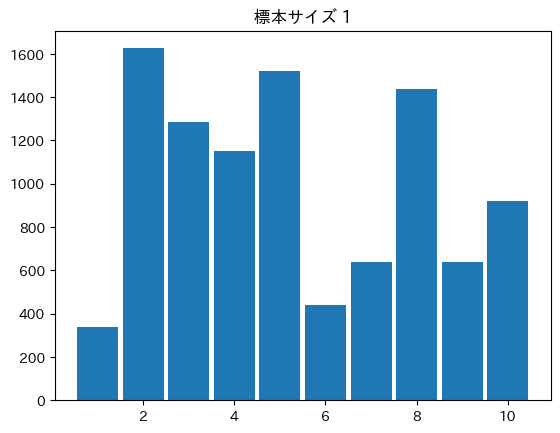


標本サイズ = 10
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 0.7388834
母分散÷標本サイズ = 0.7342623
誤差             = 0.0046211


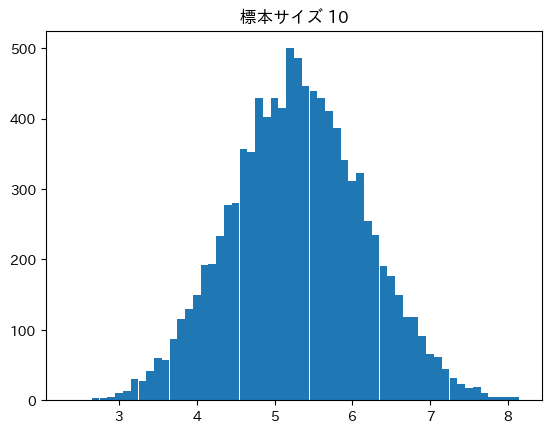


標本サイズ = 100
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 0.0725785
母分散÷標本サイズ = 0.0734262
誤差             = 0.0008477


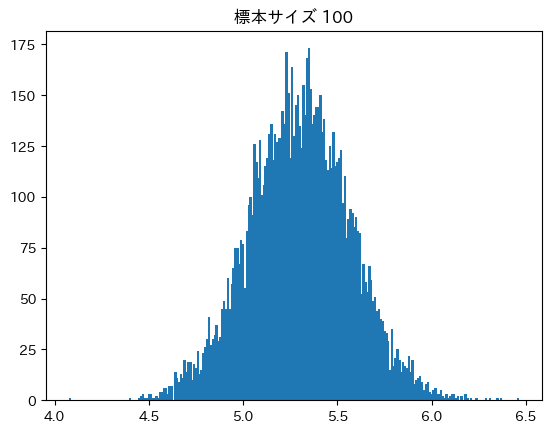


標本サイズ = 1000
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 0.0073988
母分散÷標本サイズ = 0.0073426
誤差             = 0.0000561


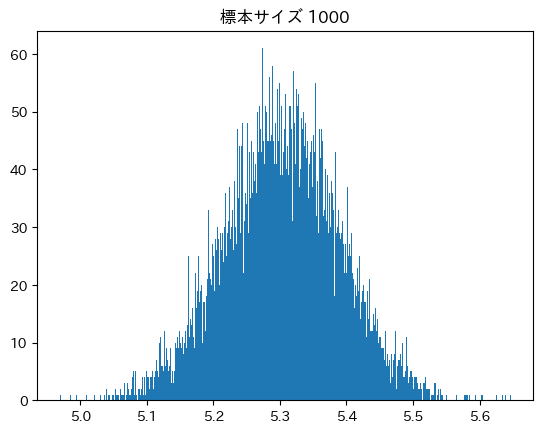


標本サイズ = 10000
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 0.0007441
母分散÷標本サイズ = 0.0007343
誤差             = 0.0000098


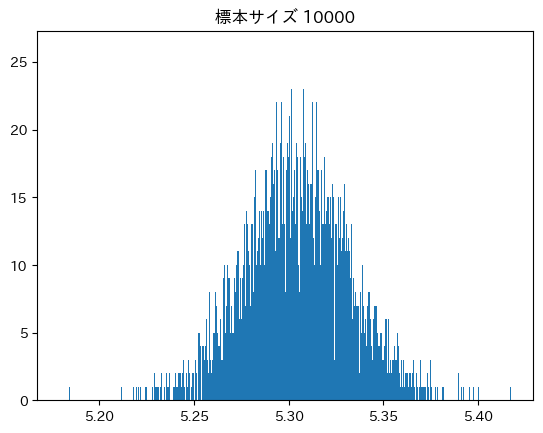

In [17]:
for size in [1, 10, 100, 1000, 10000]:
    sampling_and_analyze(X, P, size, 10000)
    print()


In [ ]:
def sampling_and_analyze(X, P, size, num, bins, maxe=1000000):
    print(f"標本サイズ = {size}")
    E = np.average(X, weights=P)
    V = np.average(X ** 2, weights=P) - E ** 2
    print(f"母平均           = {E:.7f}")
    print(f"母分散           = {V:.7f}")

    numleft = num
    maxs = min(size, maxe)
    maxn = min(num, maxe // maxs)
    mean = []
    while numleft > 0:
        sizeleft = size
        n = min(numleft, maxn)
        total = np.zeros(n)
        while sizeleft > 0:
            s = min(sizeleft, maxe)
            sample = np.random.choice(X, p=P, size=(s, n)) 
            total += np.sum(sample, axis=0)  
            sizeleft -= s
        mean += (total / size).tolist()
        numleft -= n
    var = np.var(mean)
    print(f"標本平均の分散    = {var:.7f}") 
    print(f"母分散÷標本サイズ = {V/size:.7f}") 
    print(f"誤差             = {np.abs(var - V/size):.7f}") 
    
    plt.hist(mean, bins=bins)
    plt.title(f"標本サイズ {size}")
    plt.show()

標本サイズ = 1000
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 0.0072864
母分散÷標本サイズ = 0.0073426
誤差             = 0.0000562


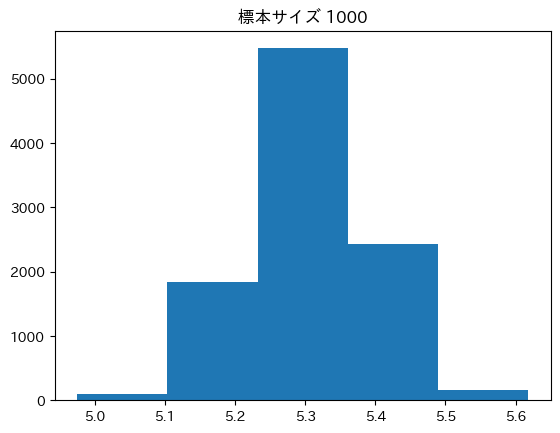

標本サイズ = 1000
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 0.0073367
母分散÷標本サイズ = 0.0073426
誤差             = 0.0000059


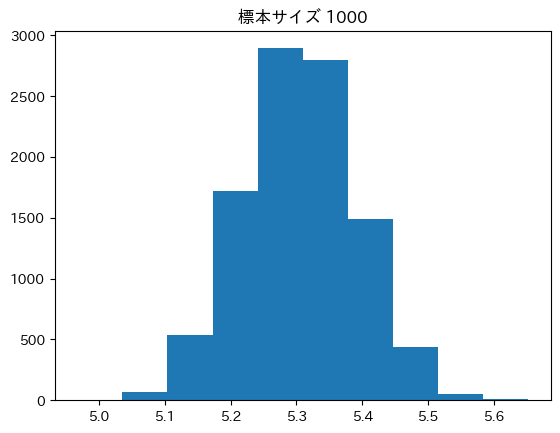

標本サイズ = 1000
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 0.0072890
母分散÷標本サイズ = 0.0073426
誤差             = 0.0000536


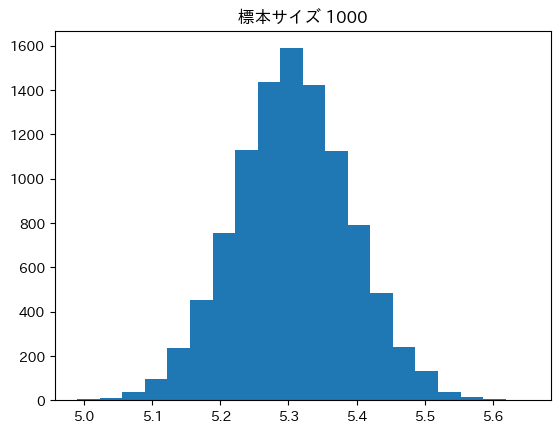

標本サイズ = 1000
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 0.0073235
母分散÷標本サイズ = 0.0073426
誤差             = 0.0000191


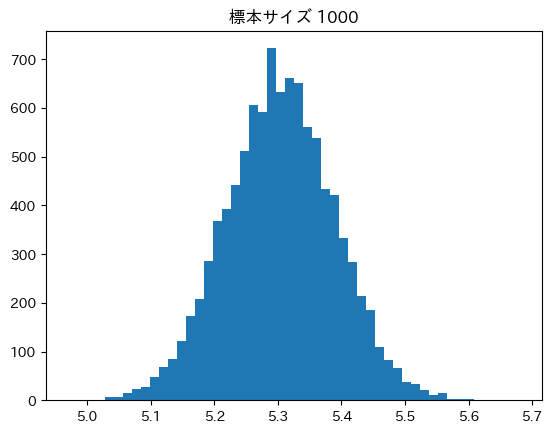

標本サイズ = 1000
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 0.0072866
母分散÷標本サイズ = 0.0073426
誤差             = 0.0000560


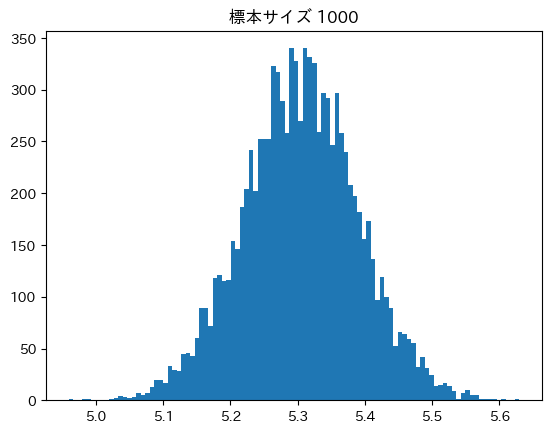

In [19]:
for bins in [5, 10, 20, 50, 100]:
    sampling_and_analyze(X, P, 1000, 10000, bins=bins)

In [ ]:
def sampling_and_analyze(X, P, size, num, bins=None, maxe=1000000):
    print(f"標本サイズ = {size}")
    E = np.average(X, weights=P)
    V = np.average(X ** 2, weights=P) - E ** 2
    print(f"母平均           = {E:.7f}")
    print(f"母分散           = {V:.7f}")

    numleft = num
    maxs = min(size, maxe)
    maxn = min(num, maxe // maxs)
    mean = []
    while numleft > 0:
        sizeleft = size
        n = min(numleft, maxn)
        total = np.zeros(n)
        while sizeleft > 0:
            s = min(sizeleft, maxe)
            sample = np.random.choice(X, p=P, size=(s, n)) 
            total += np.sum(sample, axis=0)  
            sizeleft -= s
        mean += (total / size).tolist()
        numleft -= n
    var = np.var(mean)
    print(f"標本平均の分散    = {var:.7f}") 
    print(f"母分散÷標本サイズ = {V/size:.7f}") 
    print(f"誤差             = {np.abs(var - V/size):.7f}") 
    
    if bins is None:
        element = np.unique(mean)
        bins = max(len(X), min(int(np.sqrt(len(element))) * 2, 50))
    plt.hist(mean, bins=bins)
    plt.title(f"標本サイズ {size}")
    plt.show()

標本サイズ = 1
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 7.3689320
母分散÷標本サイズ = 7.3426229
誤差             = 0.0263092


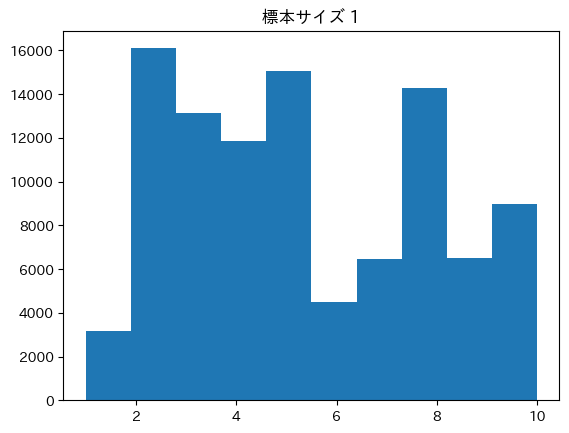


標本サイズ = 10
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 0.7273915
母分散÷標本サイズ = 0.7342623
誤差             = 0.0068708


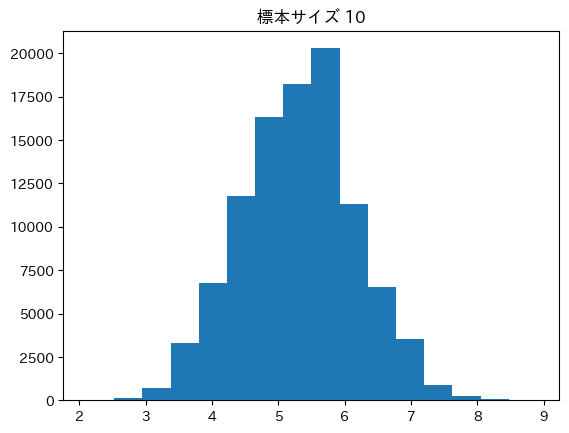


標本サイズ = 100
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 0.0738291
母分散÷標本サイズ = 0.0734262
誤差             = 0.0004029


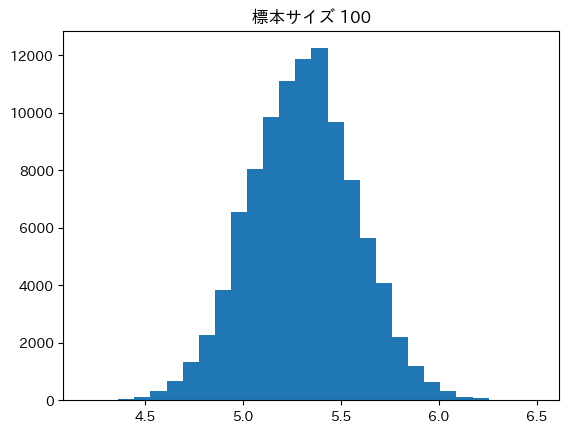


標本サイズ = 1000
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 0.0073287
母分散÷標本サイズ = 0.0073426
誤差             = 0.0000139


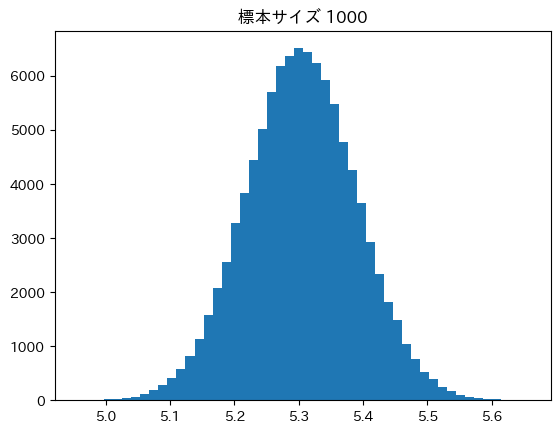


標本サイズ = 10000
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 0.0007380
母分散÷標本サイズ = 0.0007343
誤差             = 0.0000038


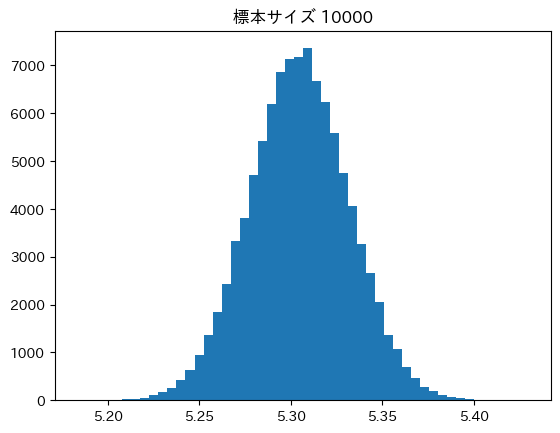

In [21]:
for size in [1, 10, 100, 1000, 10000]:
    sampling_and_analyze(X, P, size, 100000)
    print()

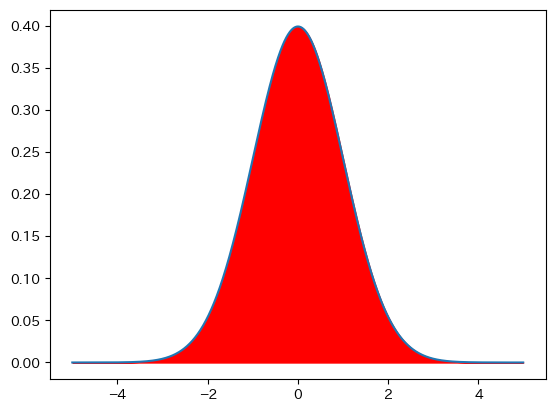

In [22]:
from statistics import NormalDist

ndist = NormalDist(0, 1)
NX = [x / 100 for x in range(-500, 500)]
NY = [ndist.pdf(x) for x in NX]
plt.plot(NX, NY)
plt.fill_between(NX, 0, NY, color="r")
plt.show()

In [ ]:
def sampling_and_analyze(X, P, size, num, bins=None, maxe=1000000):
    print(f"標本サイズ = {size}")
    E = np.average(X, weights=P)
    V = np.average(X ** 2, weights=P) - E ** 2
    print(f"母平均           = {E:.7f}")
    print(f"母分散           = {V:.7f}")

    numleft = num
    maxs = min(size, maxe)
    maxn = min(num, maxe // maxs)
    mean = []
    while numleft > 0:
        sizeleft = size
        n = min(numleft, maxn)
        total = np.zeros(n)
        while sizeleft > 0:
            s = min(sizeleft, maxe)
            sample = np.random.choice(X, p=P, size=(s, n)) 
            total += np.sum(sample, axis=0)  
            sizeleft -= s
        mean += (total / size).tolist()
        numleft -= n
    var = np.var(mean)
    print(f"標本平均の分散    = {var:.7f}") 
    print(f"母分散÷標本サイズ = {V/size:.7f}") 
    print(f"誤差             = {np.abs(var - V/size):.7f}") 
    
    if bins is None:
        element = np.unique(mean)
        bins = max(len(X), min(int(np.sqrt(len(element))) * 2, 50))
    plt.hist(mean, bins=bins, density=True)
    ndist = NormalDist(E, np.sqrt(V/size))
    NX = np.linspace(min(mean), max(mean), 100)
    NY = [ndist.pdf(x) for x in NX]
    plt.plot(NX, NY)
    plt.title(f"標本サイズ {size}")
    plt.show()

標本サイズ = 1
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 7.3189706
母分散÷標本サイズ = 7.3426229
誤差             = 0.0236523


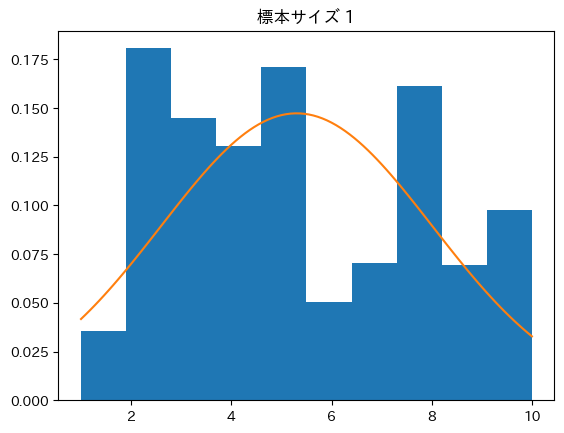

標本サイズ = 2
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 3.6791022
母分散÷標本サイズ = 3.6713114
誤差             = 0.0077907


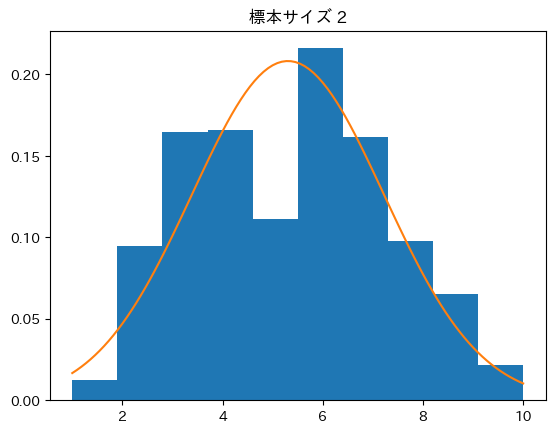

標本サイズ = 3
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 2.4503033
母分散÷標本サイズ = 2.4475410
誤差             = 0.0027623


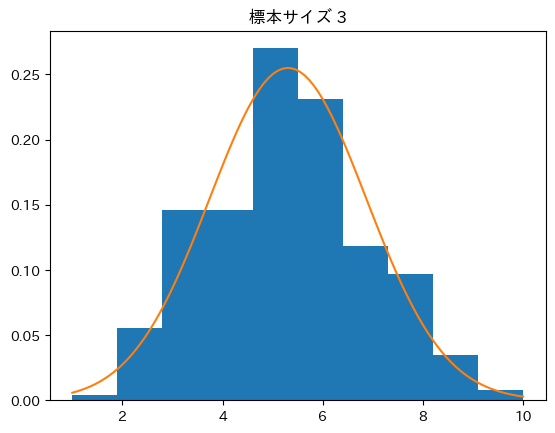

標本サイズ = 5
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 1.4707107
母分散÷標本サイズ = 1.4685246
誤差             = 0.0021861


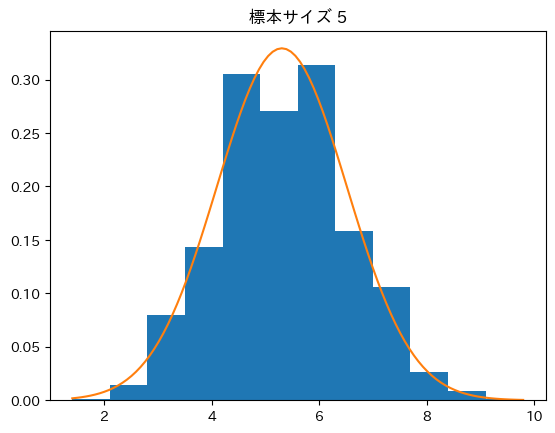

標本サイズ = 10
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 0.7349576
母分散÷標本サイズ = 0.7342623
誤差             = 0.0006953


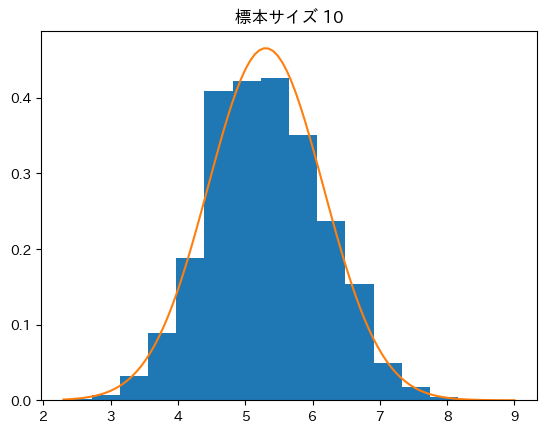

標本サイズ = 100
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 0.0729644
母分散÷標本サイズ = 0.0734262
誤差             = 0.0004618


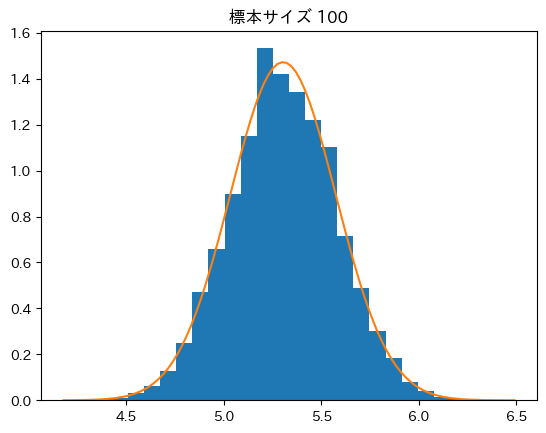

標本サイズ = 1000
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 0.0072825
母分散÷標本サイズ = 0.0073426
誤差             = 0.0000601


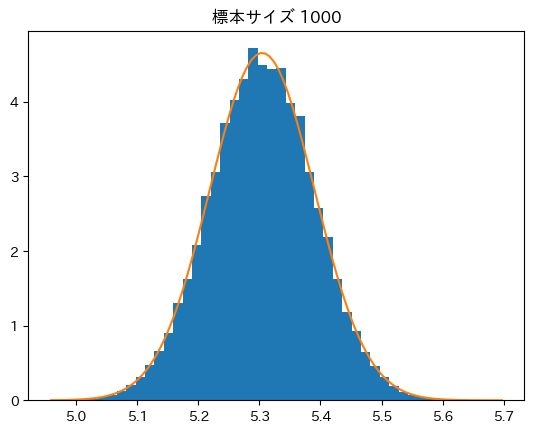

標本サイズ = 10000
母平均           = 5.3044915
母分散           = 7.3426229
標本平均の分散    = 0.0007379
母分散÷標本サイズ = 0.0007343
誤差             = 0.0000036


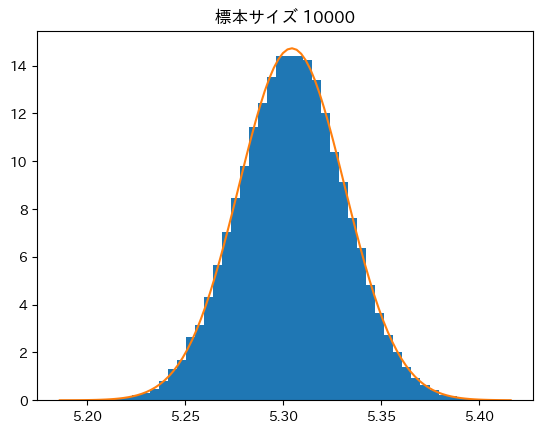

In [24]:
for size in [1, 2, 3, 5, 10, 100, 1000, 10000]:
    sampling_and_analyze(X, P, size, 100000)

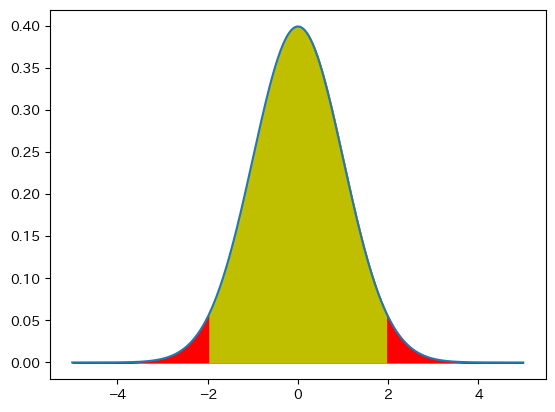

In [25]:
ndist = NormalDist(0, 1)
NX = [x / 100 for x in range(-500, 500)]
NY = [ndist.pdf(x) for x in NX]
plt.plot(NX, NY)
plt.fill_between(NX, 0, NY, color="r")
plt.fill_between(NX[500-196:500+196], 0, NY[500-196:500+196], color="y")
plt.show()

In [26]:
def betY(size):
    prize = np.pow(2 ** 0.5, -np.floor(np.log2(np.random.uniform(size=size))) - 1)
    mean = np.cumsum(prize) / np.arange(1, size + 1)
    plt.plot(mean)
    plt.xlabel("賭けの回数")
    plt.ylabel("賞金の平均")   

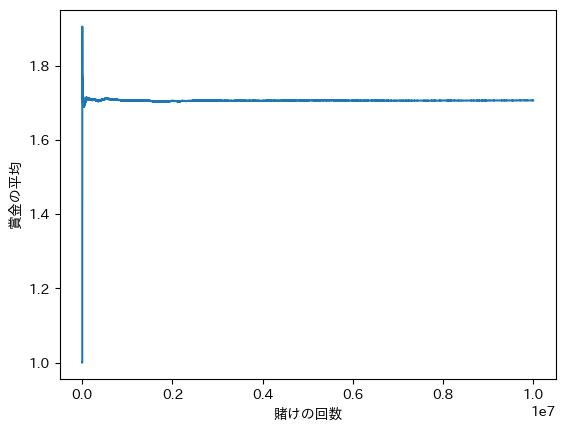

In [27]:
betY(10000000)